In [3]:
pip install seaborn


Defaulting to user installation because normal site-packages is not writeable
Note: you may need to restart the kernel to use updated packages.


In [4]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import PolynomialFeatures
from sklearn.metrics import mean_squared_error, r2_score

In [6]:
# 1. Load dataset directly from Seaborn
df = sns.load_dataset('mpg')
# Preprocess missing values (drop rows where displacement or mpg is missing)
df = df.dropna(subset=['displacement', 'mpg'])

X = df[['displacement']]  # Independent variable
y = df['mpg']             # Target variable

# Split data (80:20 ratio, random_state=42)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [7]:
lin_reg = LinearRegression()
lin_reg.fit(X_train, y_train)
y_pred_lin = lin_reg.predict(X_test)

mse_lin = mean_squared_error(y_test, y_pred_lin)
r2_lin = r2_score(y_test, y_pred_lin)


In [8]:
degrees = [2, 3, 4]
poly_models = {}
metrics = {'Linear (Deg 1)': {'MSE': mse_lin, 'R2': r2_lin}}

for degree in degrees:
    # Generate polynomial features
    poly = PolynomialFeatures(degree=degree)
    X_train_poly = poly.fit_transform(X_train)
    X_test_poly = poly.transform(X_test)
    
    # Train linear regression model on polynomial features
    poly_reg = LinearRegression()
    poly_reg.fit(X_train_poly, y_train)
    
    # Predict on test data
    y_pred_poly = poly_reg.predict(X_test_poly)
    
    # Store results
    metrics[f'Polynomial (Deg {degree})'] = {
        'MSE': mean_squared_error(y_test, y_pred_poly),
        'R2': r2_score(y_test, y_pred_poly)
    }
    poly_models[degree] = (poly, poly_reg)


In [9]:
results_df = pd.DataFrame(metrics).T
print("=== Model Comparison Metrics ===")
display(results_df)


=== Model Comparison Metrics ===


,MSE,R2
Linear (Deg 1),18.102544,0.663311
Polynomial (Deg 2),15.107354,0.719019
Polynomial (Deg 3),14.943632,0.722064
Polynomial (Deg 4),14.961487,0.721732


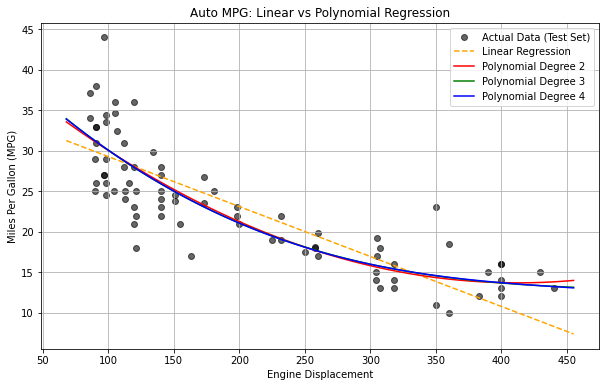

In [14]:
import warnings
warnings.filterwarnings("ignore", category=UserWarning)

# Create smooth range of values across displacement for plotting curves
X_grid = pd.DataFrame({'displacement': np.linspace(X['displacement'].min(), X['displacement'].max(), 300)})

# Extract a pure NumPy array for the X-axis plotting to avoid Pandas indexing errors
x_plot = X_grid['displacement'].to_numpy()

plt.figure(figsize=(10, 6))
# Using X_test['displacement'] instead of just X_test in case X_test is a DataFrame
plt.scatter(X_test['displacement'].to_numpy(), y_test.to_numpy(), color='black', alpha=0.6, label='Actual Data (Test Set)')

# Plot Linear Fit
plt.plot(x_plot, lin_reg.predict(X_grid), label='Linear Regression', linestyle='--', color='orange')

# Plot Polynomial Fits
colors = ['red', 'green', 'blue']
for degree, color in zip(degrees, colors):
    poly, model = poly_models[degree]
    X_grid_poly = poly.transform(X_grid)
    plt.plot(x_plot, model.predict(X_grid_poly), label=f'Polynomial Degree {degree}', color=color)

plt.xlabel('Engine Displacement')
plt.ylabel('Miles Per Gallon (MPG)')
plt.title('Auto MPG: Linear vs Polynomial Regression')
plt.legend()
plt.grid(True)
plt.show()